In [ ]:

import torch
from torch.nn.utils.rnn import pack_padded_sequence, pad_packed_sequence
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.decomposition import PCA
import pandas as pd

import json
import sys
import os
models_path = os.path.abspath(os.path.join('models'))
sys.path.append(models_path)

from DKT.dkt_model import DKT

In [24]:

# Load the configuration file
with open('data/models/best_dkt_config.json', 'r') as f:
    config = json.load(f)

# Step 3: Instantiate the model
model = DKT(**config['models_params'])

# Step 4: Load the saved parameters
# Step 4: Load the saved parameters
model.load_state_dict(torch.load('data/models/best_dkt_model.pth', map_location=torch.device('cpu')))
model.eval()  # Set the model to evaluation mode

# Step 5: Use the model to generate embeddings
def generate_embeddings(inputs):
    with torch.no_grad():
        embedded = model.embedding(inputs[:, :, 0] * 2 - inputs[:, :, 1])
        return embedded


C:\Users\bokovacs\AppData\Local\Temp\ipykernel_4772\2612231488.py:10: FutureWarning: You are using `torch.load` with `weights_only=False` (the current default value), which uses the default pickle module implicitly. It is possible to construct malicious pickle data which will execute arbitrary code during unpickling (See https://github.com/pytorch/pytorch/blob/main/SECURITY.md#untrusted-models for more details). In a future release, the default value for `weights_only` will be flipped to `True`. This limits the functions that could be executed during unpickling. Arbitrary objects will no longer be allowed to be loaded via this mode unless they are explicitly allowlisted by the user via `torch.serialization.add_safe_globals`. We recommend you start setting `weights_only=True` for any use case where you don't have full control of the loaded file. Please open an issue on GitHub for any issues related to this experimental feature.
  model.load_state_dict(torch.load('data/models/best_dkt_mo

In [32]:
num_embeddings = int((model.embedding.num_embeddings - 1) / 2)
embedding_dim = model.embedding.embedding_dim

In [67]:

# Step 1: Create a DataFrame with `answer_id` from 1 to `num_embeddings` and `correct` set to 1
df = pd.DataFrame({
    'problem_id': range(1, num_embeddings + 1),
    'correct': 1
})

# Step 2: Calculate embeddings for each `answer_id`
# Create a tensor with the `answer_id` values, reshape to match input shape and get the embeddings
input_tensor = torch.tensor([[[i, 1] for i in range(1, num_embeddings + 1)]]).long()  # Shape: (1, num_embeddings, 2)

embeddings = generate_embeddings(input_tensor)  # Shape: (1, num_embeddings, embedding_dim)
embeddings = embeddings.squeeze(0)  # Remove the batch dimension to shape (num_embeddings, embedding_dim)

# Step 3: Add the calculated embeddings as columns to the DataFrame
# Convert embeddings to a list and add each dimension as a new column
embedding_list = embeddings.tolist()  # Shape: (num_embeddings, embedding_dim)
embedding_df = pd.DataFrame(embedding_list, columns=[f'embed_{i+1}' for i in range(embedding_dim)])

# Concatenate `df` with the embedding DataFrame
df = pd.concat([df, embedding_df], axis=1)

# Display the resulting DataFrame
print(df.head())  # Print the first few rows to check the structure


   problem_id  correct   embed_1   embed_2   embed_3   embed_4   embed_5  \
0           1        1  0.888681 -0.847292  0.213682 -2.035403  0.523639   
1           2        1 -1.134202  1.209532 -1.068941 -1.046031  0.251826   
2           3        1  0.984941  1.220255 -1.413289  1.932290  1.143891   
3           4        1  1.299874 -0.419816  0.403016 -0.235870 -0.472202   
4           5        1 -0.256645 -1.033638 -0.892583 -0.970816  0.534952   

    embed_6   embed_7   embed_8   embed_9  
0  0.101720  0.105269  0.773777 -1.094815  
1 -0.951760  1.233905  0.112118  0.792693  
2 -1.272863 -0.329960  0.675409 -1.288013  
3 -0.466357 -1.136660  0.481107 -1.238752  
4 -1.085762  1.965129  0.450252  0.393070  


In [49]:
df

,answer_id,correct,embed_1,embed_2,embed_3,embed_4,embed_5,embed_6,embed_7,embed_8,embed_9,pca1,pca2
0,1,1,0.888681,-0.847292,0.213682,-2.035403,0.523639,0.101720,0.105269,0.773777,-1.094815,-1.942423,-0.824449
1,2,1,-1.134202,1.209532,-1.068941,-1.046031,0.251826,-0.951760,1.233905,0.112118,0.792693,-1.140802,1.474662
2,3,1,0.984941,1.220255,-1.413289,1.932290,1.143891,-1.272863,-0.329960,0.675409,-1.288013,1.357331,-0.257095
3,4,1,1.299874,-0.419816,0.403016,-0.235870,-0.472202,-0.466357,-1.136660,0.481107,-1.238752,0.294444,-1.041287
4,5,1,-0.256645,-1.033638,-0.892583,-0.970816,0.534952,-1.085762,1.965129,0.450252,0.393070,-2.134737,-0.748409
...,...,...,...,...,...,...,...,...,...,...,...,...,...
8204,8205,1,-0.207887,2.466883,0.847983,-0.800039,2.142832,-0.211081,0.240015,0.060555,-0.442792,-0.818950,1.901859
8205,8206,1,-0.549891,-1.930931,-1.306393,-0.835808,1.424471,0.035202,-0.920583,-0.219975,0.342207,-0.953207,-0.316882
8206,8207,1,0.138542,1.177823,-1.071336,1.647958,-0.935860,-0.015213,0.766511,-0.342778,-1.855671,1.404869,0.221750
8207,8208,1,-1.281409,0.280855,1.427303,1.125935,1.700179,-0.524199,-0.118955,0.125509,-0.693498,0.629345,0.008128


In [50]:
df_answers = pd.read_csv('data/preprocessed/answers_reindexed_df.csv')
df_skills = pd.read_csv('data/preprocessed/skills_df.csv')


In [63]:
df_skills_merged = df_skills.merge(df_answers[['problem_id', 'problem_id_reindexed']].drop_duplicates(), on='problem_id', how='left')

In [69]:
df_merged = df.merge(df_skills_merged[['skill_id', 'problem_id_reindexed']], left_on = 'problem_id', right_on='problem_id_reindexed', how='inner')


In [77]:
num_skills = df_skills_merged['skill_id'].nunique()


In [ ]:
from sklearn.cluster import KMeans
from sklearn.preprocessing import StandardScaler

# Step 1: Select columns for clustering
cols_to_cluster = [f'embed_{i}' for i in range(1, 10)]
data_to_cluster = df_merged[cols_to_cluster]

# Step 2: Standardize the data
scaler = StandardScaler()
data_scaled = scaler.fit_transform(data_to_cluster)

# Step 3: Apply K-Means clustering
kmeans = KMeans(n_clusters=num_skills, random_state=42)  # Adjust `n_clusters` as needed
df_merged['cluster'] = kmeans.fit_predict(data_scaled)



In [129]:
# Step 1: Count occurrences of each (cluster, skill_id) pair
confusion_data = df_merged.groupby(['cluster', 'skill_id']).size().reset_index(name='count')

# Step 2: Pivot to create confusion matrix
confusion_matrix = confusion_data.pivot(index='cluster', columns='skill_id', values='count')

# Step 3: Replace NaN with 0 for missing values
confusion_matrix = confusion_matrix.fillna(0).astype(int)

# Display the confusion matrix
confusion_matrix


skill_id,1,2,4,5,8,9,10,11,12,13,...,310,311,312,317,322,323,325,368,375,378
cluster,,,,,,,,,,,,,,,,,,,,,
0,1,3,1,0,0,1,1,3,0,3,...,0,8,2,0,0,2,2,1,0,0
1,2,3,0,1,1,3,6,4,0,3,...,2,12,6,0,0,1,1,1,1,0
2,1,7,0,0,1,7,5,1,2,1,...,4,10,1,0,0,3,0,0,0,0
3,1,4,3,1,0,1,3,0,3,3,...,1,8,1,0,0,0,1,1,1,0
4,1,2,0,0,1,4,1,2,2,3,...,0,13,1,0,0,0,0,1,0,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
80,3,1,2,1,2,2,2,2,3,1,...,2,11,1,1,0,1,1,0,1,0
81,3,1,0,1,1,3,3,6,3,1,...,2,12,4,0,0,1,4,0,1,0
82,0,2,1,0,0,2,2,1,2,0,...,3,10,2,1,0,1,0,0,0,0


In [126]:
for i in range(85):
    print(df_merged.loc[df_merged['cluster']==i, 'skill_id'].nunique())

39
60
56
46
47
51
59
42
48
48
55
50
50
52
50
51
54
47
52
54
53
47
47
50
51
55
49
52
51
45
47
47
45
52
49
50
53
53
50
54
47
56
51
55
46
48
46
44
62
48
47
59
50
49
45
51
55
45
53
52
55
48
52
51
42
41
55
51
56
45
52
45
60
49
56
40
47
49
43
48
61
56
47
52
49


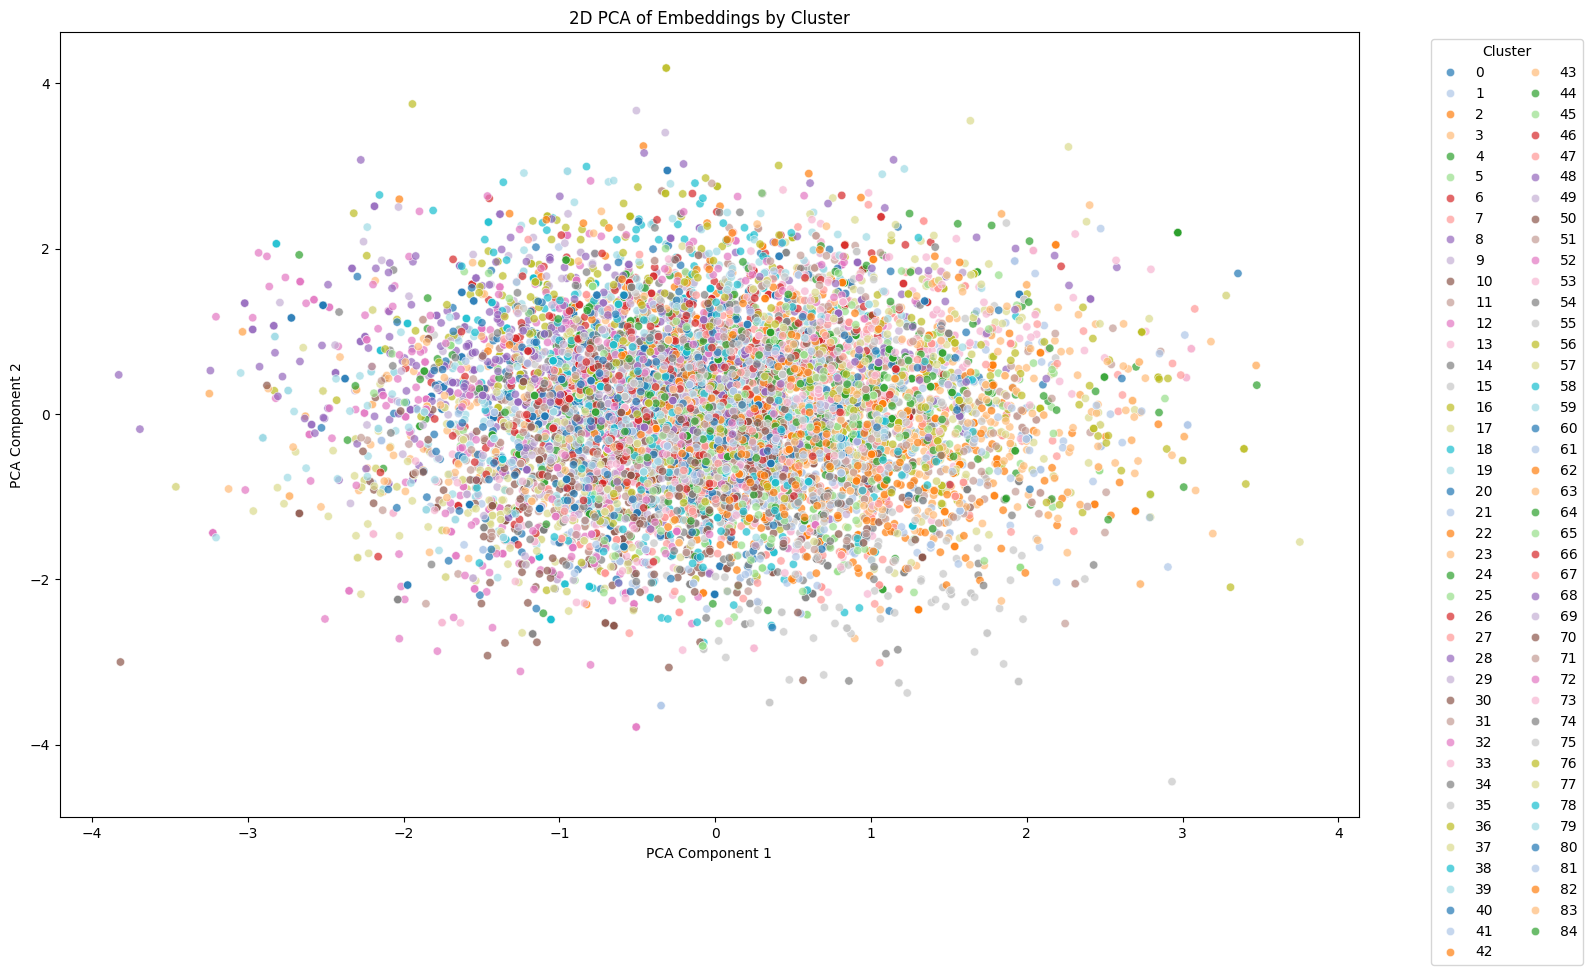

In [134]:
import seaborn as sns
import matplotlib.pyplot as plt
from sklearn.decomposition import PCA

# Define the embedding dimension based on your DataFrame structure
embedding_dim = 9  # Adjust to the number of embedding columns

# Extract the embedding columns from the DataFrame
embedding_cols = [f'embed_{i}' for i in range(1, embedding_dim + 1)]
embeddings = df_merged[embedding_cols].values

# Apply PCA to reduce embeddings to 2D
pca = PCA(n_components=2)
pca_result = pca.fit_transform(embeddings)

# Add PCA results to the DataFrame
df_merged['pca1'] = pca_result[:, 0]
df_merged['pca2'] = pca_result[:, 1]

# Plotting with a categorical palette for distinct clusters
plt.figure(figsize=(16, 10))
sns.scatterplot(
    x='pca1', 
    y='pca2', 
    hue='cluster', 
    palette=sns.color_palette('tab20', n_colors=85),  # Use a palette that supports many clusters
    data=df_merged, 
    alpha=0.7,
    legend='full'
)
plt.title('2D PCA of Embeddings by Cluster')
plt.xlabel('PCA Component 1')
plt.ylabel('PCA Component 2')
plt.legend(title='Cluster', bbox_to_anchor=(1.05, 1), loc='upper left', ncol=2)
plt.tight_layout()
plt.show()


In [135]:
df_skills['skill_name'].unique()

array(['Circle Graph', nan, 'Percent Of', 'Equivalent Fractions',
       'Finding Percents', 'Proportion', 'Median', 'Range', 'Table',
       'Mean', 'Multiplication and Division Integers',
       'Equation Solving Two or Fewer Steps',
       'Equation Solving More Than Two Steps',
       'Addition and Subtraction Positive Decimals',
       'Addition and Subtraction Integers', 'Congruence',
       'Multiplication Fractions', 'Addition and Subtraction Fractions',
       'Addition Whole Numbers', 'Ordering Integers',
       'Ordering Positive Decimals',
       'Order of Operations +,-,/,* () positive reals',
       'Surface Area Rectangular Prism',
       'Calculations with Similar Figures',
       'Probability of a Single Event', 'Fraction Of', 'Mode',
       'Conversion of Fraction Decimals Percents',
       'Subtraction Whole Numbers', 'Absolute Value',
       'Ordering Fractions', 'Unit Conversion Within a System',
       'Multiplication and Division Positive Decimals',
       'Divis

No useful results - switching to train on a skill level instead of an answer level.